# Loan Default Risk Analysis

by Collins Kimotho

The project analyzes borrower and load data to identify the key factors driving loan defaults and support reducing the default rate from 25% to 12%

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

from dotenv import load_dotenv
import os

load_dotenv()


%matplotlib inline
warnings.filterwarnings('ignore')

## Data Gathering

In [2]:
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SHOW TABLES", engine)
print(df)


  Tables_in_loan_default_risk_analysis
0                    borrower_profiles
1                    loan_applications


In [3]:
profiles_df = pd.read_sql_table("borrower_profiles", engine)
profiles_df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [4]:
profiles_df = pd.read_sql_table("borrower_profiles", engine)
profiles_df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [5]:
applications_df = pd.read_sql_table("loan_applications", engine)
applications_df.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0



## Exploratory Data Analysis

Borrower Profiles

In [6]:
profiles_df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [7]:
print(f'The borrower profile DataFrame has {profiles_df.shape[0]} rows and {profiles_df.shape[1]}columns')

The borrower profile DataFrame has 500 rows and 11columns


In [8]:
# Review the data types
profiles_df.dtypes

borrower_id                str
age                      int64
state                      str
education_level            str
employment_status          str
years_employed           int64
annual_income            int64
credit_score             int64
home_ownership             str
dependents               int64
existing_monthly_debt    int64
dtype: object

In [9]:
# Basic statistics
profiles_df.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [10]:
# Check nulls
profiles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   borrower_id            500 non-null    str  
 1   age                    500 non-null    int64
 2   state                  500 non-null    str  
 3   education_level        500 non-null    str  
 4   employment_status      500 non-null    str  
 5   years_employed         500 non-null    int64
 6   annual_income          500 non-null    int64
 7   credit_score           500 non-null    int64
 8   home_ownership         500 non-null    str  
 9   dependents             500 non-null    int64
 10  existing_monthly_debt  500 non-null    int64
dtypes: int64(6), str(5)
memory usage: 43.1 KB


In [11]:
# Confirm nulls
profiles_df.isnull().sum()

borrower_id              0
age                      0
state                    0
education_level          0
employment_status        0
years_employed           0
annual_income            0
credit_score             0
home_ownership           0
dependents               0
existing_monthly_debt    0
dtype: int64

In [27]:
sum(profiles_df.duplicated())

0

In [12]:
# get the unique values
def get_unique_values(df, columns):
    for col in columns:
        print(f"Column: {col} ({df[col].nunique()}) unique values")
        print(df[col].unique())
        print("-"*40)    

In [13]:
get_unique_values(profiles_df, ['state','education_level', 'employment_status', 'home_ownership'])

Column: state (30) unique values
<StringArray>
['CT', 'CO', 'NC', 'TX', 'NY', 'OR', 'GA', 'KY', 'UT', 'WA', 'FL', 'AL', 'IN',
 'CA', 'AZ', 'MA', 'OH', 'MO', 'TN', 'NJ', 'MN', 'VA', 'MD', 'SC', 'LA', 'IL',
 'PA', 'WI', 'OK', 'MI']
Length: 30, dtype: str
----------------------------------------
Column: education_level (5) unique values
<StringArray>
['High School', 'Bachelor', 'Doctorate', 'Master', 'Associate']
Length: 5, dtype: str
----------------------------------------
Column: employment_status (5) unique values
<StringArray>
['Self-Employed', 'Full-Time', 'Contract', 'Part-Time', 'Retired']
Length: 5, dtype: str
----------------------------------------
Column: home_ownership (3) unique values
<StringArray>
['Rent', 'Own', 'Mortgage']
Length: 3, dtype: str
----------------------------------------


#### Loan applications

In [ ]:
applications_df.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [ ]:
print(f'The loan applications DataFrame has {applications_df.shape[0]} rows and {applications_df.shape[1]}columns')

The loan applications DataFrame has 601 rows and 12columns


In [ ]:
applications_df.dtypes

loan_id                 str
borrower_id             str
application_date        str
loan_purpose            str
loan_amount         float64
term_months           int64
interest_rate       float64
monthly_payment     float64
dti_ratio           float64
loan_status             str
days_delinquent       int64
defaulted             int64
dtype: object

In [ ]:
applications_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           601 non-null    str    
 1   borrower_id       601 non-null    str    
 2   application_date  601 non-null    str    
 3   loan_purpose      601 non-null    str    
 4   loan_amount       601 non-null    float64
 5   term_months       601 non-null    int64  
 6   interest_rate     601 non-null    float64
 7   monthly_payment   601 non-null    float64
 8   dti_ratio         601 non-null    float64
 9   loan_status       601 non-null    str    
 10  days_delinquent   601 non-null    int64  
 11  defaulted         601 non-null    int64  
dtypes: float64(4), int64(3), str(5)
memory usage: 56.5 KB


In [ ]:
applications_df.describe()

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


In [28]:
sum(applications_df.duplicated())

0

In [ ]:
get_unique_values(applications_df, ['loan_purpose', 'loan_status'])

Column: loan_purpose (10) unique values
<StringArray>
[          'Vacation',     'Major Purchase',             'Moving',
          'Auto Loan',          'Education',   'Medical Expenses',
   'Home Improvement',      'Business Loan', 'Debt Consolidation',
            'Wedding']
Length: 10, dtype: str
----------------------------------------
Column: loan_status (4) unique values
<StringArray>
['Paid Off', 'Default', 'Current', 'Late']
Length: 4, dtype: str
----------------------------------------


### Merge DataFrames

In [29]:
loans_df = pd.merge(profiles_df, applications_df, on='borrower_id', how='inner')
loans_df.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [30]:
# Overall default rate
loans_df['defaulted'].mean()

np.float64(0.24292845257903495)

In [31]:
#Credit Score buckets
bins = [500, 600, 650, 700, 750, 850]
labels = ['520-599', '600-649', '650-699', '700-799', '750+']

loans_df['credit_bucket'] = pd.cut(loans_df['credit_score'], bins=bins, labels=labels)

loans_df[['credit_score', 'credit_bucket']].head()

,credit_score,credit_bucket
0,596,520-599
1,596,520-599
2,543,520-599
3,611,600-649
4,701,700-799


## Segment Analysis

In [33]:
loans_df.groupby('credit_bucket')['defaulted'].mean()

credit_bucket
520-599    0.491525
600-649    0.282609
650-699    0.282051
700-799    0.152941
750+       0.118421
Name: defaulted, dtype: float64

There is a clear inverse relationship between credit score and default rate:
* Lower credit scores = significantly higher risk
* Higher credit scores = more reliable borrowers

In [35]:
bins = [0, 20, 35,50, 100]
labels = ['0-20', '20-35', '35-50', '50+']

loans_df['dti_bucket'] = pd.cut(loans_df['dti_ratio'], bins=bins, labels=labels)

loans_df[['dti_ratio', 'dti_bucket']].head()

,dti_ratio,dti_bucket
0,55.5,50+
1,40.4,35-50
2,70.5,50+
3,59.8,50+
4,44.1,35-50


In [37]:
loans_df.groupby('dti_bucket')['defaulted'].mean()

dti_bucket
0-20     0.166667
20-35    0.105263
35-50    0.206667
50+      0.342742
Name: defaulted, dtype: float64

As DTI increases, default risk generally increases - especially beyond 35%

In [39]:
# Loan purpose vs default rate
loans_df.groupby('loan_purpose')['defaulted'].mean().sort_values(ascending=False)

loan_purpose
Wedding               0.321429
Home Improvement      0.285714
Auto Loan             0.271186
Business Loan         0.241379
Education             0.226415
Vacation              0.225806
Major Purchase        0.220588
Debt Consolidation    0.215686
Moving                0.214286
Medical Expenses      0.205882
Name: defaulted, dtype: float64

In [41]:
loans_df.groupby('defaulted')['loan_amount'].mean().sort_values(ascending=False)

defaulted
1    22570.547945
0    22012.747253
Name: loan_amount, dtype: float64

In [43]:
loans_df.groupby('loan_purpose').agg({
    'defaulted':'mean',
    'loan_amount': 'mean'
}).sort_values(by='defaulted', ascending=False)

,defaulted,loan_amount
loan_purpose,,
Wedding,0.321429,21892.857143
Home Improvement,0.285714,23407.142857
Auto Loan,0.271186,19554.237288
Business Loan,0.241379,21013.793103
Education,0.226415,19847.169811
Vacation,0.225806,24477.419355
Major Purchase,0.220588,23164.705882
Debt Consolidation,0.215686,22756.862745
Moving,0.214286,21300.000000


#### Insight: Loan Purpose and Default Risk

Default rates vary across loan purposes, with discretionary spending categories showing higher risk. Wedding loans have the highest default rate (~32%), followed by home improvement and auto loans.

In contrast, more necessity-driven purposes such as medical expenses and debt consolidation have lower default rates (~20–21%).

This suggests that loan purpose is an important behavioral indicator of default risk and should be incorporated into underwriting decisions.


#### Insight: Loan Amount and Default Behavior

The average loan amount for defaulted borrowers (~22,570) is slightly higher than for non-defaulted borrowers (~22,013). However, the difference is relatively small, indicating that loan size alone is not a strong predictor of default risk.

This suggests that borrower characteristics such as credit score and DTI are more important drivers of default than loan amount.

In [44]:
loans_df.groupby('employment_status')['defaulted'].mean().sort_values(ascending=False)

employment_status
Part-Time        0.276923
Self-Employed    0.247619
Full-Time        0.239344
Retired          0.233333
Contract         0.227273
Name: defaulted, dtype: float64

In [48]:
bins = [0,2,5,10,100]
labels = ['<2', '2-5', '5-10', '10+']

loans_df['emp_year_bucket'] = pd.cut(loans_df['years_employed'], bins=bins, labels=labels)
loans_df[['emp_year_bucket', 'years_employed']].head()


,emp_year_bucket,years_employed
0,5-10,6
1,5-10,6
2,2-5,4
3,10+,22
4,10+,19


In [49]:
loans_df.groupby('emp_year_bucket')['defaulted'].mean()

emp_year_bucket
<2      0.322917
2-5     0.115789
5-10    0.300000
10+     0.229885
Name: defaulted, dtype: float64

#### Insight: Employment Status and Default Risk

Default rates vary slightly across employment types, with part-time workers exhibiting the highest default rate (~27.7%) and contract workers the lowest (~22.7%). This suggests that employment type has some influence on repayment behavior, although the differences are relatively modest.


#### Insight: Years Employed and Default Risk

Borrowers with less than 2 years of employment have the highest default rate (~32.3%), which is significantly higher than borrowers with 2–5 years of employment (~11.6%). This indicates that shorter employment duration is associated with increased default risk.

However, the relationship is not strictly linear, as borrowers with 5–10 years of employment also exhibit relatively high default rates (~30%). This suggests that employment duration alone is not sufficient to explain default risk and should be considered alongside other factors such as credit score and DTI.

## Correlation Analysis

In [56]:
corr = loans_df[['credit_score', 'dti_ratio', 'loan_amount', 'interest_rate', 'defaulted']].corr()

corr['defaulted'].sort_values(ascending=False)

defaulted        1.000000
interest_rate    0.198930
dti_ratio        0.192454
loan_amount      0.018116
credit_score    -0.286394
Name: defaulted, dtype: float64

<Axes: >

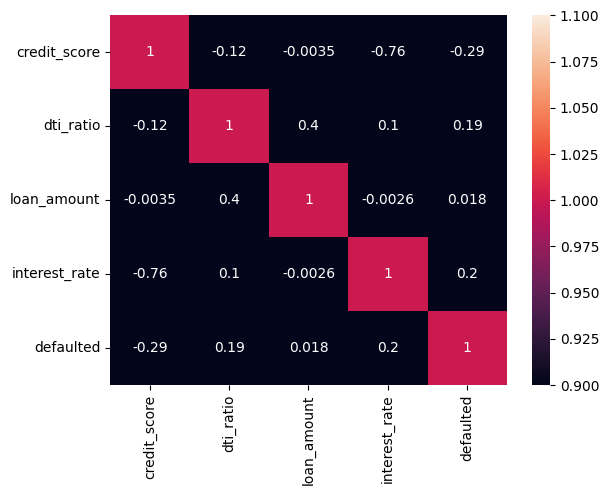

In [60]:
sns.heatmap(corr, vmin=1, vmax=1, annot=True)

#### Insight: Correlation Analysis of Default Risk

Correlation analysis indicates that credit score has the strongest relationship with default risk, showing a moderate negative correlation (~ -0.29). This confirms that borrowers with higher credit scores are less likely to default.

Debt-to-income ratio (DTI) and interest rate both show moderate positive correlations with default (~0.19 and ~0.20 respectively), suggesting that higher debt burden and borrowing costs increase the likelihood of default.

In contrast, loan amount exhibits a negligible correlation (~0.02), indicating that loan size alone is not a strong predictor of default risk.

Overall, default risk is driven by a combination of factors, with credit score, DTI, and interest rate emerging as the most influential numerical variables.

In [61]:
loans_df.to_csv("loan_analysis_ready.csv", index=False)